In [1]:
import pandas as pd

df = pd.read_csv("database/human_vital_signs_dataset_2024.csv")

df.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [2]:
df.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [3]:
df.shape

(200020, 17)

In [4]:
df.columns

Index(['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Timestamp',
       'Body Temperature', 'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'Risk Category'],
      dtype='object')

In [6]:
df.isnull().sum()

Patient ID                  0
Heart Rate                  0
Respiratory Rate            0
Timestamp                   0
Body Temperature            0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Age                         0
Gender                      0
Weight (kg)                 0
Height (m)                  0
Derived_HRV                 0
Derived_Pulse_Pressure      0
Derived_BMI                 0
Derived_MAP                 0
Risk Category               0
dtype: int64

## Exploratory Data Analysis (EDA)

EDA is performed to understand the behavior of patient vital signs and identify normal versus abnormal physiological patterns.

The analysis includes:

- Distribution analysis of heart rate, SpO₂, temperature, and blood pressure
- Identification of extreme values and potential outliers
- Understanding baseline physiological ranges for anomaly detection
- Visualization of relationships between vital signs

These insights help guide the design of the anomaly detection models.

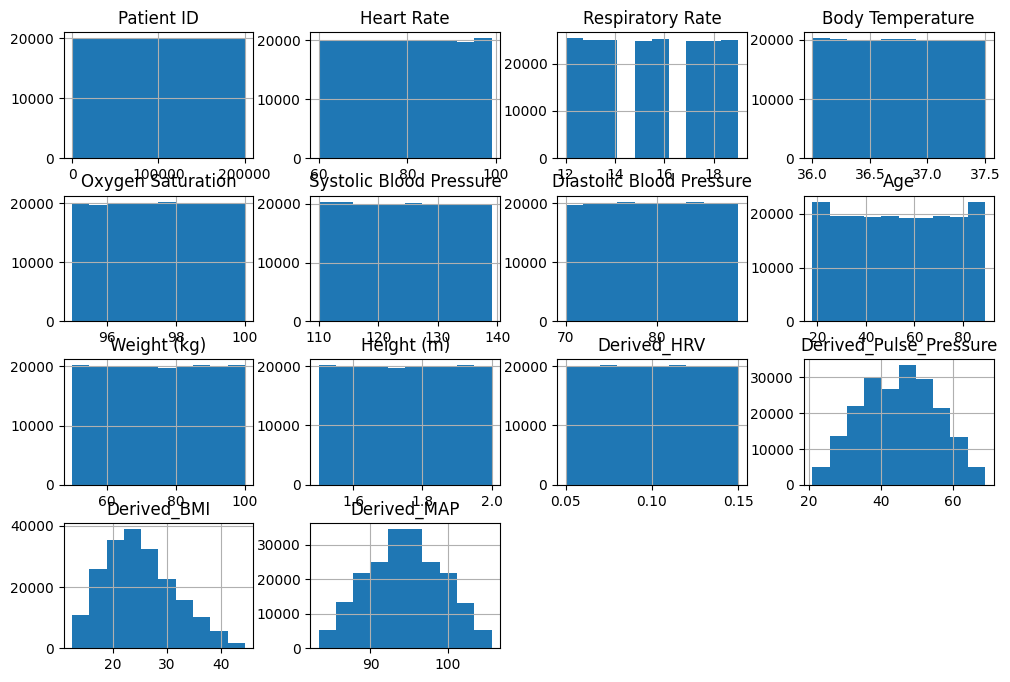

In [9]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

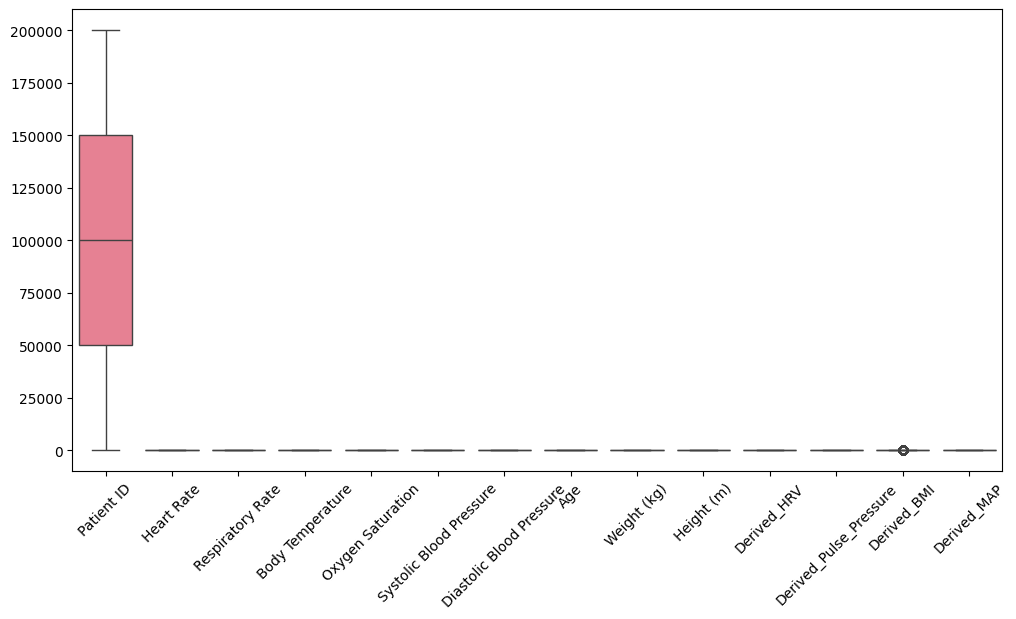

In [11]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=['float','int']))
plt.xticks(rotation=45)
plt.show()

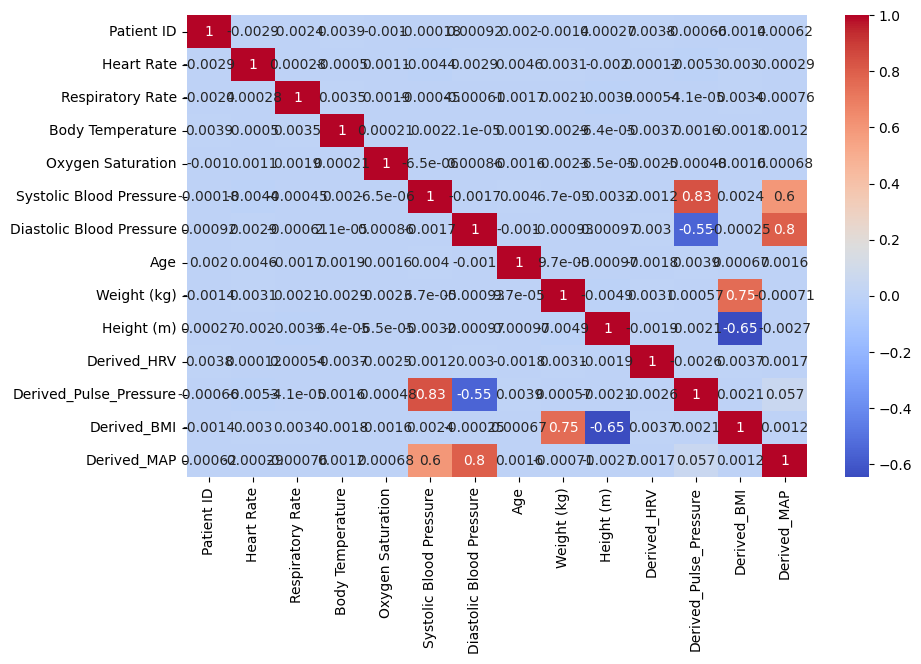

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [5]:
df = df.drop(columns=["Patient ID"])

## Feature Preparation

After exploratory data analysis, relevant physiological features are selected for anomaly detection.

The following vital signs are used as input features:

- Heart Rate
- Respiratory Rate
- Body Temperature
- Oxygen Saturation (SpO₂)
- Systolic Blood Pressure
- Diastolic Blood Pressure
- Derived Heart Rate Variability (HRV)
- Derived Mean Arterial Pressure (MAP)

These features collectively represent the physiological state of a patient and are useful for identifying abnormal patterns in vital signs.

In [5]:
features = [
    "Heart Rate",
    "Respiratory Rate",
    "Body Temperature",
    "Oxygen Saturation",
    "Systolic Blood Pressure",
    "Diastolic Blood Pressure",
    "Derived_HRV",
    "Derived_MAP"
]

X = df[features]

X.head()

,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Derived_HRV,Derived_MAP
0,60,12,36.861707,95.702046,124,86,0.121033,98.666667
1,63,18,36.511633,96.689413,126,84,0.117062,98.000000
2,63,15,37.052049,98.508265,131,78,0.053200,95.666667
3,99,16,36.654748,95.011801,118,72,0.064475,87.333333
4,69,16,36.975098,98.623792,138,76,0.118484,96.666667


In [6]:
print("Selected Features Shape:", X.shape)
print("Selected Features:", X.columns)

Selected Features Shape: (200020, 8)
Selected Features: Index(['Heart Rate', 'Respiratory Rate', 'Body Temperature',
       'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Derived_HRV', 'Derived_MAP'],
      dtype='object')


In [7]:
df = df.drop(columns=[
   
    "Gender",
    "Timestamp",
    "Risk Category"
])

In [8]:
df.columns

Index(['Patient ID', 'Heart Rate', 'Respiratory Rate', 'Body Temperature',
       'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Weight (kg)', 'Height (m)',
       'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI', 'Derived_MAP'],
      dtype='object')

In [9]:
from sklearn.preprocessing import MinMaxScaler

# select vital features
df_vitals = df[
    [
        'Heart Rate',
        'Respiratory Rate',
        'Body Temperature',
        'Oxygen Saturation',
        'Systolic Blood Pressure',
        'Diastolic Blood Pressure',
        'Derived_HRV',
        'Derived_MAP'
    ]
]

scaler = MinMaxScaler()

scaled_vitals = scaler.fit_transform(df_vitals)

df_scaled = pd.DataFrame(
    scaled_vitals,
    columns=df_vitals.columns
)

df_scaled.head()

,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Derived_HRV,Derived_MAP
0,0.000000,0.000000,0.574473,0.140409,0.482759,0.842105,0.710335,0.686567
1,0.076923,0.857143,0.341088,0.337884,0.551724,0.736842,0.670621,0.656716
2,0.076923,0.428571,0.701369,0.701658,0.724138,0.421053,0.031997,0.552239
3,1.000000,0.571429,0.436499,0.002359,0.275862,0.105263,0.144746,0.179104
4,0.230769,0.571429,0.650068,0.724763,0.965517,0.315789,0.684848,0.597015


In [10]:
df_scaled.describe()

,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Derived_HRV,Derived_MAP
count,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000
mean,0.500865,0.498493,0.498903,0.500878,0.497861,0.499980,0.499707,0.499063
std,0.296228,0.327782,0.288863,0.288522,0.298515,0.303013,0.288610,0.214831
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.256410,0.142857,0.248408,0.251373,0.241379,0.263158,0.249548,0.343284
50%,0.512821,0.428571,0.498495,0.501929,0.482759,0.473684,0.499881,0.492537
75%,0.769231,0.714286,0.748672,0.751150,0.758621,0.736842,0.749179,0.656716
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Temporal Modeling using Sliding Window

Patient vital signs are time-series data. Instead of analyzing each reading independently, a sliding window approach is used to capture temporal dependencies between consecutive observations.

A sliding window groups multiple consecutive measurements into a single sample, allowing the anomaly detection models to detect sustained abnormal patterns rather than isolated noisy readings.

In [11]:
import numpy as np

def create_sliding_windows(data, window_size):
    windows = []

    for i in range(len(data) - window_size + 1):
        window = data[i:i+window_size]
        windows.append(window)

    return np.array(windows)

In [12]:
window_size = 5

X_windows = create_sliding_windows(df_scaled.values, window_size)

print("Windowed data shape:", X_windows.shape)

Windowed data shape: (200016, 5, 8)


In [15]:
X_windows_flat = X_windows.reshape(X_windows.shape[0], -1)

print("Flattened shape:", X_windows_flat.shape)

Flattened shape: (200016, 40)


In [16]:
X_windows_flat[:3]

array([[0.        , 0.        , 0.5744733 , 0.14040903, 0.48275862,
        0.84210526, 0.71033488, 0.68656716, 0.07692308, 0.85714286,
        0.34108849, 0.33788429, 0.55172414, 0.73684211, 0.67062125,
        0.65671642, 0.07692308, 0.42857143, 0.70136868, 0.70165782,
        0.72413793, 0.42105263, 0.03199689, 0.55223881, 1.        ,
        0.57142857, 0.43649907, 0.00235899, 0.27586207, 0.10526316,
        0.14474557, 0.17910448, 0.23076923, 0.57142857, 0.65006756,
        0.72476342, 0.96551724, 0.31578947, 0.68484819, 0.59701493],
       [0.07692308, 0.85714286, 0.34108849, 0.33788429, 0.55172414,
        0.73684211, 0.67062125, 0.65671642, 0.07692308, 0.42857143,
        0.70136868, 0.70165782, 0.72413793, 0.42105263, 0.03199689,
        0.55223881, 1.        , 0.57142857, 0.43649907, 0.00235899,
        0.27586207, 0.10526316, 0.14474557, 0.17910448, 0.23076923,
        0.57142857, 0.65006756, 0.72476342, 0.96551724, 0.31578947,
        0.68484819, 0.59701493, 0.48717949, 0. 

In [17]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X_windows_flat)

# Anomaly scores
iso_scores = -iso_forest.decision_function(X_windows_flat)

# Binary anomaly labels
iso_anomalies = iso_forest.predict(X_windows_flat)

iso_scores[:10], iso_anomalies[:10]

(array([-0.03476705, -0.05023722, -0.02766051, -0.039484  , -0.04697916,
        -0.04840717, -0.06918673, -0.06315699, -0.04947462, -0.05270306]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_windows_flat.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(128, activation="relu")(input_layer)
encoded = Dense(64, activation="relu")(encoded)
encoded = Dense(32, activation="relu")(encoded)

decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,176 (121.78 KB)

 Trainable params: 31,176 (121.78 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = autoencoder.fit(
    X_windows_flat,
    X_windows_flat,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0781 - val_loss: 0.0370
Epoch 2/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0368 - val_loss: 0.0366
Epoch 3/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0364 - val_loss: 0.0364
Epoch 4/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0362 - val_loss: 0.0363
Epoch 5/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0361 - val_loss: 0.0364
Epoch 6/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0360 - val_loss: 0.0362
Epoch 7/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0360 - val_loss: 0.0362
Epoch 8/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0360 - val_loss: 0.0363
Epoch 9/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0360 - val_loss: 0.0360
Epoch 10/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0359 - val_loss: 0.0359
Epoch 11/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0359 - val_loss: 0.0361
Epoch 12/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [27]:
import os
os.makedirs("models/", exist_ok=True)

In [28]:
import joblib

# Save autoencoder
autoencoder.save("models/autoencoder_model.keras")

# Save scaler
joblib.dump(scaler, "models/scaler.pkl")

# Save Isolation Forest
joblib.dump(iso_forest, "models/isolation_forest.pkl")

['models/isolation_forest.pkl']

In [30]:
import os

os.listdir("models")

['autoencoder_model.keras', 'isolation_forest.pkl', 'scaler.pkl']

In [31]:
import numpy as np

# Reconstruct input using autoencoder
reconstructed = autoencoder.predict(X_windows_flat)

# Reconstruction error (MSE)
reconstruction_error = np.mean(
    np.power(X_windows_flat - reconstructed, 2),
    axis=1
)

reconstruction_error[:10]

6251/6251 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


array([0.0407647 , 0.02881748, 0.03856131, 0.03411568, 0.03032567,
       0.03311541, 0.02653562, 0.01902051, 0.02465324, 0.02481471])

In [32]:
threshold = np.percentile(reconstruction_error, 95)
print("Anomaly Threshold:", threshold)

Anomaly Threshold: 0.050115217303854875


In [33]:
autoencoder_anomalies = reconstruction_error > threshold

In [34]:
autoencoder_anomalies[:10]

array([False, False, False, False, False, False, False, False, False,
       False])

In [35]:
def classify_severity(score):
    
    if score < threshold:
        return "LOW"
    
    elif score < threshold * 1.5:
        return "MEDIUM"
    
    else:
        return "HIGH"


severity_levels = [classify_severity(score) for score in reconstruction_error]

severity_levels[:10]

['LOW', 'LOW', 'LOW', 'LOW', 'LOW', 'LOW', 'LOW', 'LOW', 'LOW', 'LOW']